<hr>
BT6270: Computational Neuroscience <br>
Assignment 3 <br>
By KALAIYARASU_D, BS22B019
<hr>

In [ ]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt

One class that handles both complex and power coupling


This class handles both complex and power coupling. They use the same variables and parameters (based on the assumptions in the report). The only difference is the differential equations that update each oscillator’s r and phase over time.


The differential equations that govern the dynamics of the first oscillator's state i.e., $z_1$'s parameters are: <br>
$\dot{r_1} = (\mu - r_1^2)r_1 + A r_2 \cos(\theta_2 - \theta_1 + \phi)
$ <br>
$\dot{\theta}_1 = \omega_1 + A \frac{r_2}{r_1} \sin(\theta_2 - \theta_1 + \phi)
$ <br><br>And for the second oscillator, $z_2$: <br>
$\dot{r_2} = (\mu - r_2^2)r_2 + A r_1 \cos(\theta_1 - \theta_2 - \phi)
$ <br>
$\dot{\theta}_2 = \omega_2 + A \frac{r_1}{r_2} \sin(\theta_1 - \theta_2 - \phi)
$ <br><br>
These are further described in my report.

Similarly, the differential equations that govern the dynamics of the second oscillator's state i.e., $z_2$'s parameters are: <br>
$\dot{r_1} = (\mu - r_1^2)r_1 + A_{12}  r_2^{\frac{\omega_1}{\omega_2}} \cos \left( \omega_1\left( \frac{\theta_2}{\omega_2} - \frac{\theta_1}{\omega_1} + \frac{\phi_{12}}{\omega_1 \omega_2} \right) \right)
$ <br>
$\dot{\theta}_1 = \omega_1 + A_{12} \frac{r_2^{\frac{\omega_1}{\omega_2}}}{r_1} \sin \left( \omega_1 \left( \frac{\theta_2}{\omega_2} - \frac{\theta_1}{\omega_1} + \frac{\phi_{12}}{\omega_1 \omega_2} \right) \right)
$<br><br>And for the second oscillator, $z_2$: <br>
$\dot{r_2} = (\mu - r_2^2)r_2 + A_{21}  r_2^{\frac{\omega_2}{\omega_1}} \cos \left( \omega_2\left( \frac{\theta_1}{\omega_1} - \frac{\theta_2}{\omega_2} + \frac{\phi_{21}}{\omega_1 \omega_2} \right) \right)
$ <br>
$\dot{\theta}_2 = \omega_2 + A_{21} \frac{r_1^{\frac{\omega_2}{\omega_1}}}{r_2} \sin \left( \omega_2 \left( \frac{\theta_1}{\omega_1} - \frac{\theta_2}{\omega_2} + \frac{\phi_{21}}{\omega_1 \omega_2} \right) \right)
$

These equations are implemented in the forward integration methods of the below class. Note that it can take any of the parameters as inputs, but since the question gives only 3 of them, I've initialized the other parameters randomly.

In [ ]:
class CouplingModel:
    def __init__(self, coupling_type, omega1, omega2, phi,
                 mu_param=None, radius1=None, radius2=None,
                 theta1=None, theta2=None, amplitude=None,
                 time_step=0.1, iterations=10000):

        self.coupling_type = coupling_type

        # Fixed parameters
        self.omega1 = omega1
        self.omega2 = omega2
        self.phi = phi  # assuming phi12 = phi = -phi21

        # Random initialization if not specified
        self.mu_param = random.randint(1, 10) if mu_param is None else mu_param
        self.radius1 = random.random() if radius1 is None else radius1
        self.radius2 = random.random() if radius2 is None else radius2
        self.theta1 = random.randint(-180, 180) if theta1 is None else theta1
        self.theta2 = random.randint(-180, 180) if theta2 is None else theta2
        self.amplitude = 0.2 if amplitude is None else amplitude  # A12 = A21 = amplitude

        # Simulation settings
        self.time_step = time_step
        self.iterations = iterations  # total time = iterations * time_step

        # To record evolution
        self.radius1_history = []
        self.radius2_history = []
        self.theta1_history = []
        self.theta2_history = []

    def integrate_forward(self):
        mu_param = self.mu_param
        amplitude = self.amplitude
        phi = self.phi
        omega1 = self.omega1
        omega2 = self.omega2
        dt = self.time_step
        total_steps = self.iterations

        # Forward Euler Integration
        for _ in range(total_steps):
            if self.coupling_type == 'Complex':
                # Complex coupling dynamics
                dr1 = (mu_param - self.radius1**2) * self.radius1 + amplitude * self.radius2 * np.cos(
                    math.radians(self.theta2 - self.theta1 + phi)
                )
                dtheta1 = omega1 + amplitude * (self.radius2 / self.radius1) * np.sin(
                    math.radians(self.theta2 - self.theta1 + phi)
                )

                dr2 = (mu_param - self.radius2**2) * self.radius2 + amplitude * self.radius1 * np.cos(
                    math.radians(self.theta1 - self.theta2 - phi)
                )
                dtheta2 = omega2 + amplitude * (self.radius1 / self.radius2) * np.sin(
                    math.radians(self.theta1 - self.theta2 - phi)
                )

            elif self.coupling_type == 'Power':
                # Power coupling dynamics
                dr1 = ((mu_param - self.radius1**2) * self.radius1 +
                       (amplitude * self.radius2**(omega1 / omega2)) *
                       np.cos(omega1 * math.radians(self.theta2 / omega2 - self.theta1 / omega1 + phi / (omega1 * omega2))))

                dtheta1 = (omega1 +
                           (amplitude * (self.radius2**(omega1 / omega2)) / self.radius1) *
                           np.sin(omega1 * math.radians(self.theta2 / omega2 - self.theta1 / omega1 + phi / (omega1 * omega2))))

                dr2 = ((mu_param - self.radius2**2) * self.radius2 +
                       (amplitude * self.radius1**(omega2 / omega1)) *
                       np.cos(omega2 * math.radians(self.theta1 / omega1 - self.theta2 / omega2 - phi / (omega1 * omega2))))

                dtheta2 = (omega2 +
                           (amplitude * (self.radius1**(omega2 / omega1)) / self.radius2) *
                           np.sin(omega2 * math.radians(self.theta1 / omega1 - self.theta2 / omega2 - phi / (omega1 * omega2))))

            # Update state variables
            self.radius1 += dr1 * dt
            self.theta1 += dtheta1 * dt
            self.radius2 += dr2 * dt
            self.theta2 += dtheta2 * dt

            # Record history
            self.radius1_history.append(self.radius1)
            self.radius2_history.append(self.radius2)
            self.theta1_history.append(self.theta1)
            self.theta2_history.append(self.theta2)

        return (self.radius1_history, self.radius2_history,
                self.theta1_history, self.theta2_history)


#Plotter Functions

These are two general plotting functions I've made to streamline the process of plotting the required graphs for both types of coupling.

This first plotter function is used to plot the response i.e., the state of the oscillators over time.

In [ ]:
def response_plotter(omega1, omega2, phi, coupling_type):
    # Initialize the model
    model = CouplingModel(coupling_type, omega1, omega2, phi)
    radius1_history, radius2_history, theta1_history, theta2_history = model.integrate_forward()

    # Calculate the real part of each oscillator's complex state
    # real(z) = r * cos(θ)
    oscillator1_real = radius1_history * np.cos(np.radians(theta1_history))
    oscillator2_real = radius2_history * np.cos(np.radians(theta2_history))

    # Generate time array (since dt=0.1 and iterations=10000)
    time_points = list(np.linspace(0, 10000, 10000))

    # Plot the real parts over time
    plt.figure(figsize=(16, 6))
    plt.title(f"Oscillator Response for {coupling_type} Coupling with ω₁ = {omega1}, ω₂ = {omega2}, φ = {phi}°")
    plt.plot(time_points, oscillator1_real)
    plt.plot(time_points, oscillator2_real)

    plt.legend(['Oscillator 1', 'Oscillator 2'])
    plt.ylabel("Real(z)")
    plt.xlabel("Time (0.1 s)")  # dt = 0.1 seconds in the model
    plt.show()


This second plotter function plots the phase difference (in the case of complex coupling) or normalized phase difference (for power coupling) between the two coupled oscillators over time. To show that these values converge to a constant in both complex (where it converges to φ) and power (where it converges to φ/ω1ω2) coupling at steady state irrespective of the starting point, I've plotted several trials each of which have different, random starting points for the other parameters. That constant value is demarcated by a horizontal dashed line.

In [ ]:
def phase_diff_plotter(omega1, omega2, phi, coupling_type):
    """
    Plots the phase (for Complex coupling) or normalized phase difference (for Power coupling)
    between two oscillators over time, across multiple random trials, to show convergence behavior.
    """
    colors = ['y', 'g', 'c', 'm', 'k'] * 2  # up to 10 trials
    plt.figure(figsize=(10, 6))

    for trial in range(10):
        # Initialize model with random initial conditions
        model = CouplingModel(coupling_type, omega1, omega2, phi)
        model.radius1 = np.random.uniform(0.5, 2.0)
        model.radius2 = np.random.uniform(0.5, 2.0)
        model.theta1 = np.random.uniform(0, 360)
        model.theta2 = np.random.uniform(0, 360)

        # Simulate
        r1_hist, r2_hist, theta1_hist, theta2_hist = model.integrate_forward()

        # Phase / normalized phase difference
        if coupling_type == 'Complex':
            phase_diff = np.subtract(theta2_hist, theta1_hist)  # θ2 - θ1
        elif coupling_type == 'Power':
            phase_diff = np.subtract([th2 / omega2 for th2 in theta2_hist],
                                     [th1 / omega1 for th1 in theta1_hist])
        else:
            raise ValueError("Invalid coupling type. Choose 'Complex' or 'Power'.")

        # Time array
        t = np.linspace(0, 10000, 10000)

        # Plot this trial
        plt.plot(t, phase_diff, color=colors[trial], alpha=0.7, linewidth=1.2)

    # Steady-state reference
    steady_state = phi if coupling_type == 'Complex' else phi / (omega1 * omega2)
    plt.axhline(steady_state, linestyle="--", color="black", linewidth=2,
                label=f"Steady-State = {steady_state:.2f}")

    # Labels / formatting
    plt.title(f"{'Normalized ' if coupling_type == 'Power' else ''}Phase Difference between Oscillators\n"
              f"for {coupling_type} Coupling (ω₁={omega1}, ω₂={omega2}, φ={phi}°)")
    plt.ylabel(f"{'Normalized ' if coupling_type == 'Power' else ''}Phase Difference (°)")
    plt.xlabel("Time (0.1 s)")
    plt.ylim(steady_state - 5, steady_state + 5)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


# #Complex Coupling

Given parameters:

In [ ]:
omega1 = omega2 = 5
phi1 = -47
phi2 = 98

# ##Complex coupling with a phase difference of -47 degrees:

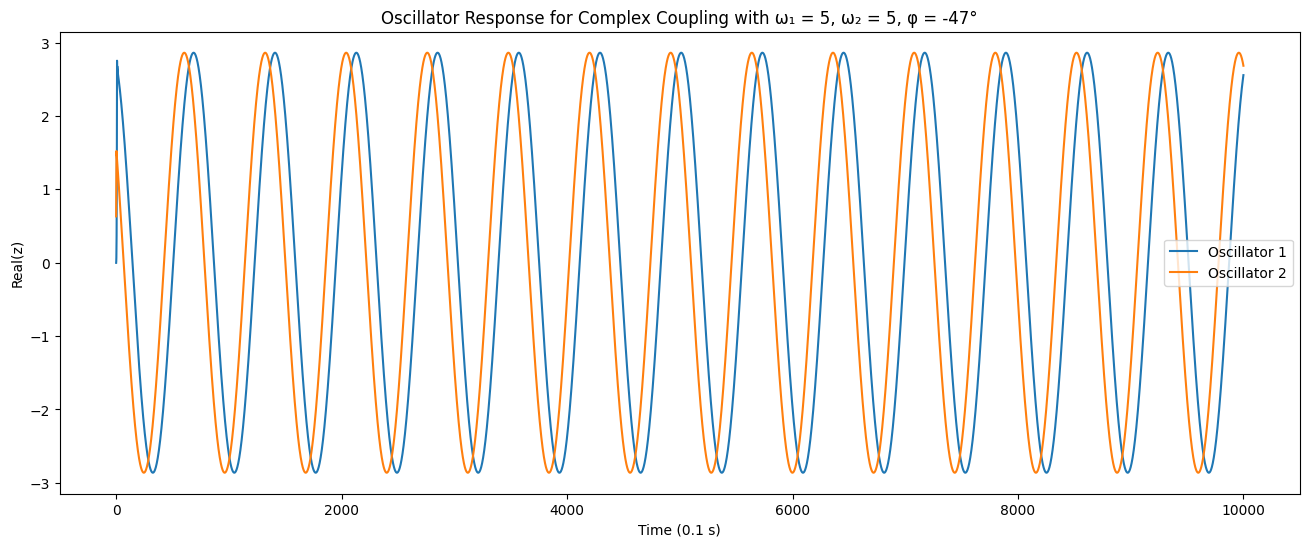

In [ ]:
response_plotter(omega1, omega2, phi1, 'Complex')

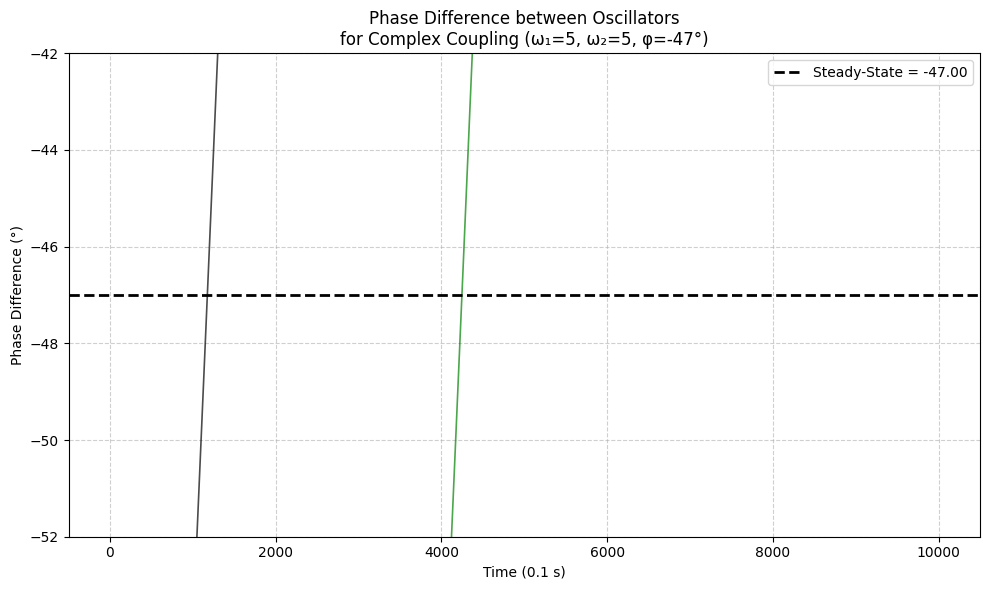

In [ ]:
phase_diff_plotter(omega1, omega2, phi1, 'Complex')


##Complex coupling with a phase difference of 98 degrees:

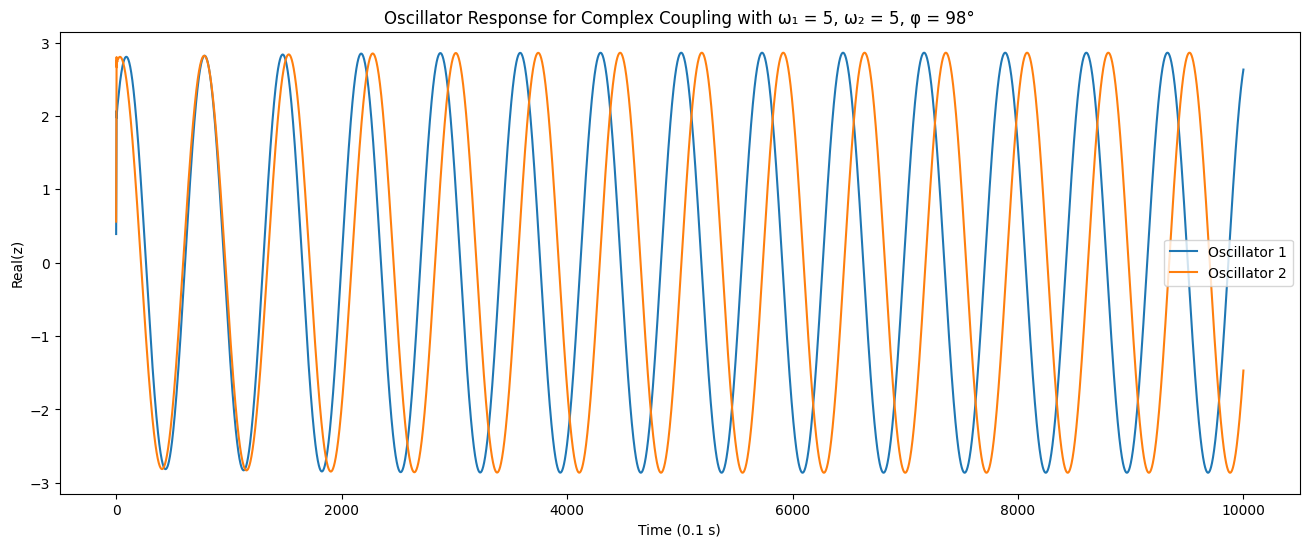

In [ ]:
response_plotter(omega1, omega2, phi2, 'Complex')

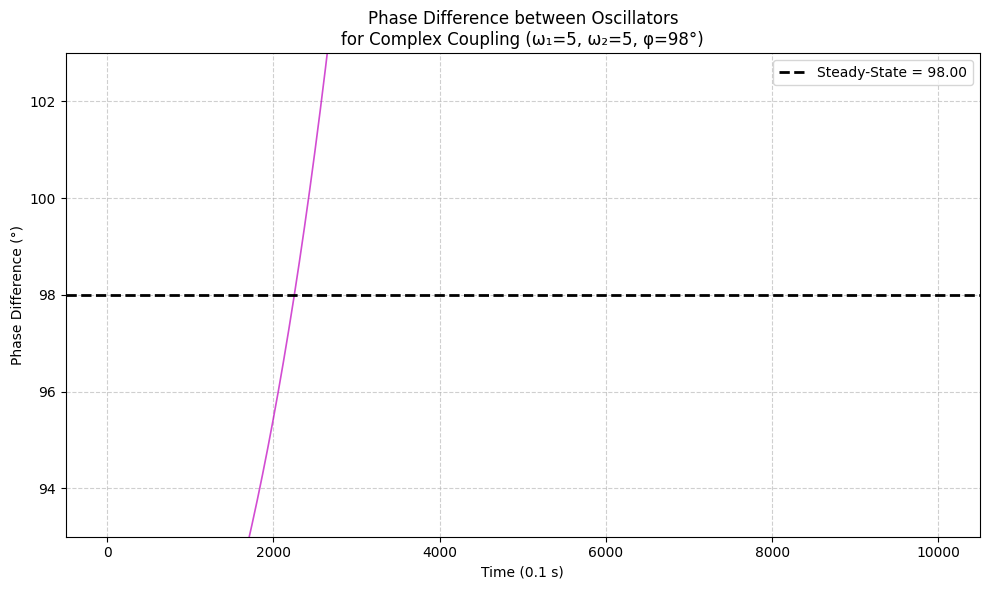

In [ ]:
phase_diff_plotter(omega1, omega2, phi2, 'Complex')

#Power Coupling

In [ ]:
ω1 = 5
ω2 = 15
φ1 = -47
φ2 = 98

Power coupling with a phase difference of -47 degrees:

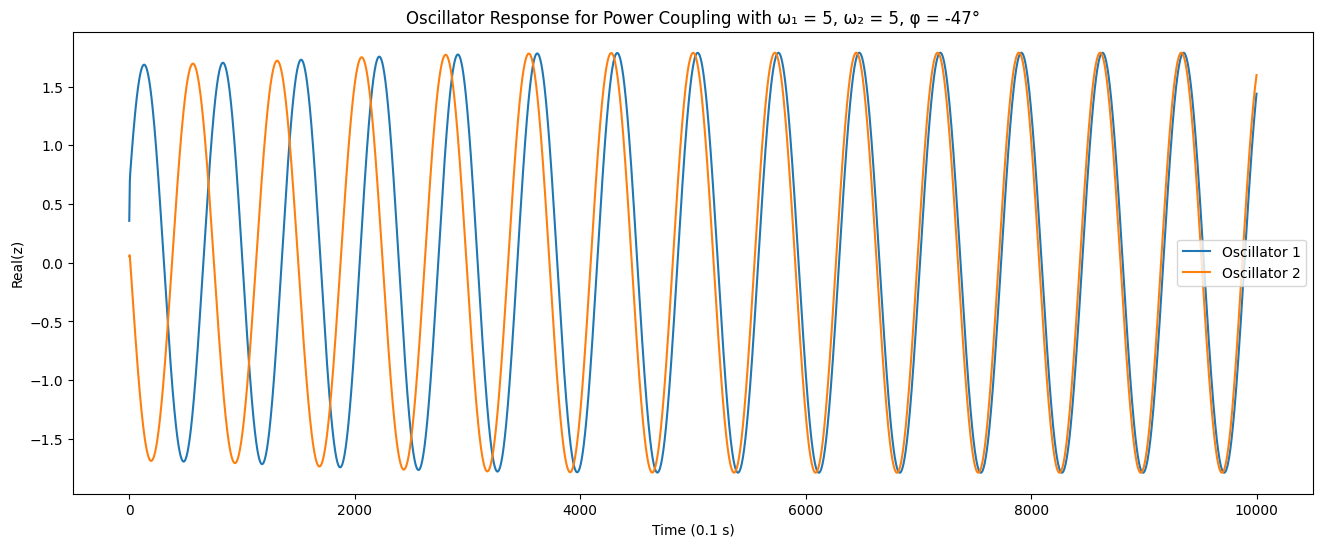

In [ ]:
response_plotter(omega1, omega2, phi1, 'Power')

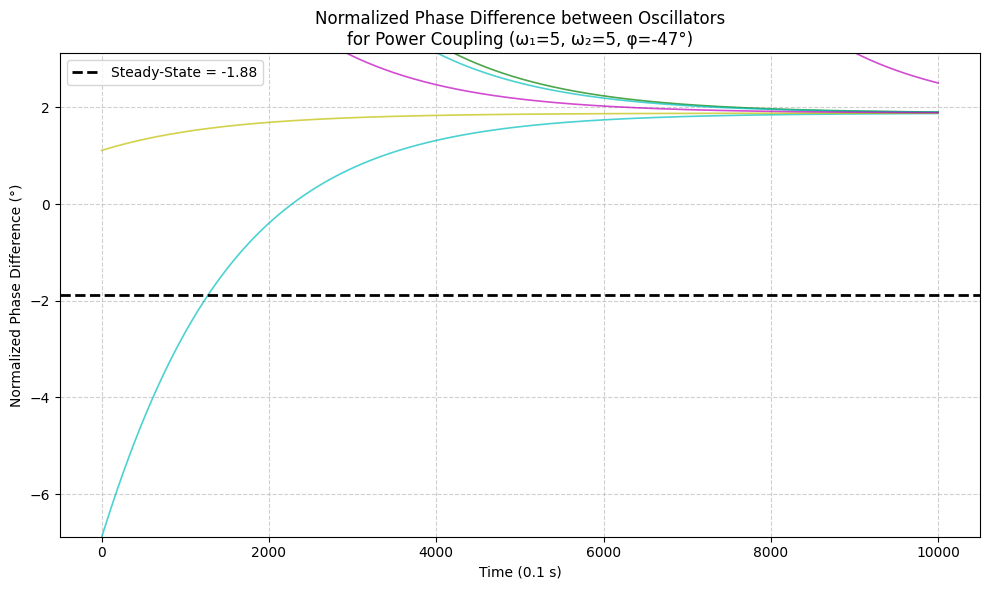

In [ ]:
phase_diff_plotter(omega1, omega2, phi1, 'Power')

Power coupling with a phase difference of 98 degrees:

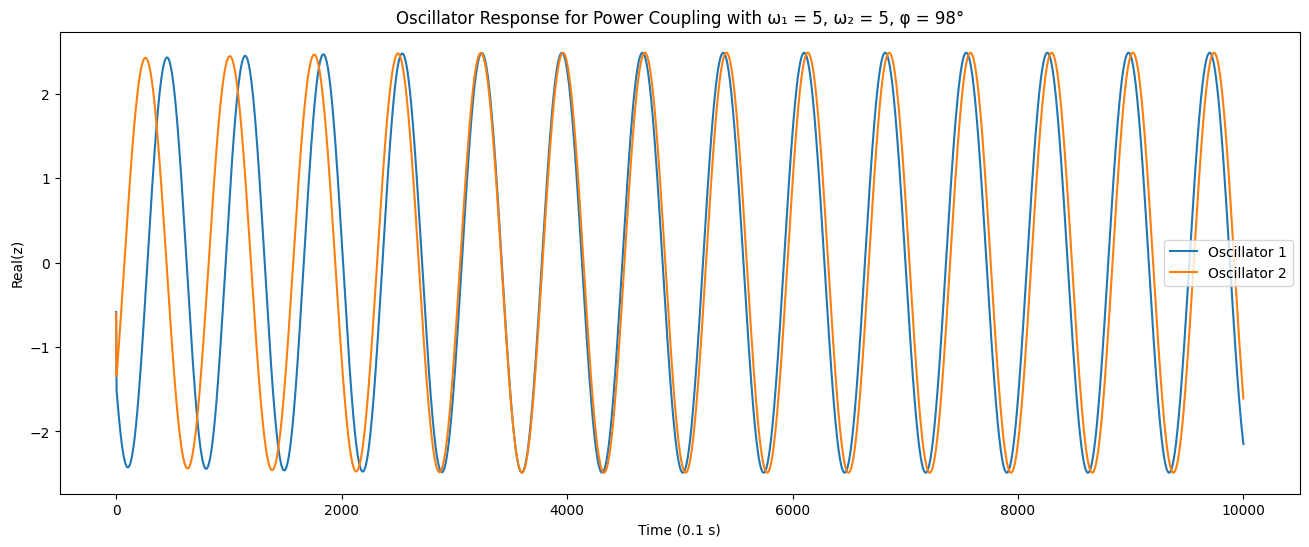

In [ ]:
response_plotter(omega1, omega2, phi2, 'Power')

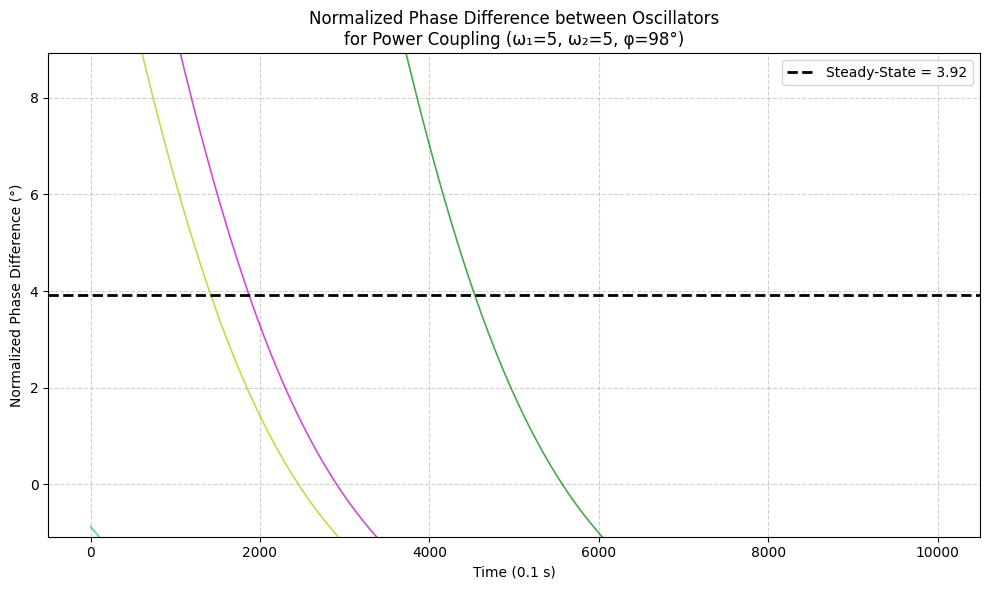

In [ ]:
phase_diff_plotter(omega1, omega2, phi2, 'Power')